# African Folktales SLM Challenge — Team Satima¶
This notebook fine-tunes Gemma-2-2b-it with LoRA to generate African-folktale-style short stories from thematic prompts, for the _African Folktales SLM Challenge_.

**Final approach:** LoRA fine-tuning (attention layers only) on all 38 training examples, trained using a "guessed" Style-cue selection (TF-IDF-matched from a 40-document pool: 24 original synthetic documents + 16 supplemental documents grounded in verified traditional African motifs), rather than the exact linked source document — this matches what the model must do at test time and was found to meaningfully improve generalization.

Sections below are ordered to match execution order. Some sections (marked as such) are retained diagnostic/experimental work that informed the final configuration but are not part of the active submission pipeline.

# Section 0: Reproducibility — fix random seeds
Controls randomness in LoRA training (dropout pattern, weight initialization)
so re-running identical code produces identical results.

In [1]:
import torch
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Random seeds fixed for reproducibility.")

Random seeds fixed for reproducibility.


# Section 1: Setup
Load libraries and attach competition data.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()

def find_data_dir():
    """Locate competition CSVs under /kaggle/input (folder naming can vary)."""
    root = Path("/kaggle/input")
    for pattern in ("competitions/african-folktales-slm-challenge",
                     "competitions/african-folktales-slm",
                     "african-folktales-slm-challenge"):
        candidate = root / pattern
        if (candidate / "train_prompts.csv").exists():
            return candidate
    for path in root.rglob("train_prompts.csv"):
        return path.parent
    raise FileNotFoundError("Could not find train_prompts.csv. Check competition data is attached.")

DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

documents = pd.read_csv(DATA_DIR / "documents.csv")
train_prompts = pd.read_csv(DATA_DIR / "train_prompts.csv")
test_prompts = pd.read_csv(DATA_DIR / "test_prompts.csv")

print("Data dir:", DATA_DIR)
print(f"{len(documents)} documents, {len(train_prompts)} train prompts, {len(test_prompts)} test prompts")

Data dir: /kaggle/input/competitions/african-folktales-slm-challenge
24 documents, 38 train prompts, 10 test prompts


# Section 2: Data Exploration
Understand the data before touching any model code — shapes, columns,
provenance, and how balanced the data is across region/theme.

In [4]:
# Confirm row/column counts match what the competition Data tab described.

print(f"Documents shape is {documents.shape} -> {documents.shape[0]} folktales, {documents.shape[1]} columns")
print(f"Train prompts shape is {train_prompts.shape} -> {train_prompts.shape[0]} prompt-story pairs, {train_prompts.shape[1]} columns")
print(f"Test prompts shape is {test_prompts.shape} -> {test_prompts.shape[0]} prompts to generate stories for, {test_prompts.shape[1]} columns")

Documents shape is (24, 8) -> 24 folktales, 8 columns
Train prompts shape is (38, 6) -> 38 prompt-story pairs, 6 columns
Test prompts shape is (10, 4) -> 10 prompts to generate stories for, 4 columns


In [5]:
# Check actual column names against the documented schema.

print("Documents columns:", list(documents.columns))
print("Train prompts columns:", list(train_prompts.columns))
print("Test prompts columns:", list(test_prompts.columns))

Documents columns: ['document_id', 'title', 'theme', 'culture_region', 'text', 'origin', 'source_url', 'license']
Train prompts columns: ['prompt', 'theme', 'culture_region', 'document_id', 'reference_story', 'PromptId']
Test prompts columns: ['PromptId', 'prompt', 'theme', 'culture_region']


In [6]:
# 2.3 Provenance check
#Is `documents.csv` genuinely synthetic, or does any row link to a real source?

print(documents[['title', 'theme', 'culture_region', 'origin', 'source_url', 'license']].to_string())

                                    title             theme   culture_region     origin  source_url  license
0           The spider and the shared pot         trickster      west_africa  synthetic         NaN  CC0-1.0
1         Tortoise and the river festival         trickster  southern_africa  synthetic         NaN  CC0-1.0
2            Hare and the drum of thunder         trickster      east_africa  synthetic         NaN  CC0-1.0
3        Why the baobab looks upside down       origin_myth      east_africa  synthetic         NaN  CC0-1.0
4           How the river learned to bend       origin_myth   central_africa  synthetic         NaN  CC0-1.0
5                   The first millet song       origin_myth      west_africa  synthetic         NaN  CC0-1.0
6   The girl who returned the lost cowrie        moral_tale      west_africa  synthetic         NaN  CC0-1.0
7               Two brothers and one path        moral_tale  southern_africa  synthetic         NaN  CC0-1.0
8   The pot that wo

In [7]:
# 2.4 Region and theme balance
# With only 24 documents / 38 training pairs across 5 regions and 6 themes,
# some combinations may be very thin — check exactly how thin.

print("Documents by region:")
print(documents['culture_region'].value_counts())
print()
print("Documents by theme:")
print(documents['theme'].value_counts())
print()
print("Train prompts by region:")
print(train_prompts['culture_region'].value_counts())
print()
print("Train prompts by theme:")
print(train_prompts['theme'].value_counts())

Documents by region:
culture_region
west_africa        6
east_africa        6
southern_africa    5
central_africa     5
diaspora           2
Name: count, dtype: int64

Documents by theme:
theme
trickster           4
origin_myth         4
moral_tale          4
hero_journey        4
animal_fable        4
community_wisdom    4
Name: count, dtype: int64

Train prompts by region:
culture_region
west_africa        10
east_africa         8
central_africa      8
southern_africa     8
diaspora            4
Name: count, dtype: int64

Train prompts by theme:
theme
community_wisdom    7
animal_fable        7
moral_tale          6
origin_myth         6
hero_journey        6
trickster           6
Name: count, dtype: int64


In [8]:
# 2.5 Test prompt distribution
# Where will the model actually be judged? Check region/theme balance in the
# 10 test prompts specifically.

print("Test prompts by region:")
print(test_prompts['culture_region'].value_counts())
print()
print("Test prompts by theme:")
print(test_prompts['theme'].value_counts())

Test prompts by region:
culture_region
east_africa        4
west_africa        2
central_africa     2
southern_africa    2
Name: count, dtype: int64

Test prompts by theme:
theme
moral_tale          2
hero_journey        2
trickster           2
origin_myth         2
animal_fable        1
community_wisdom    1
Name: count, dtype: int64


In [9]:
# 2.6 Reading actual story text
# Numbers tell us coverage, but not style. Now we read full `text` and
# `reference_story` examples to understand the actual "house style" — length,
# opening/closing conventions, how proverbs and motifs are used.

# Print 3 full documents (title + text) to see the narrative style directly.
for i in range(3):
    print("TITLE:", documents.loc[i, 'title'])
    print("THEME:", documents.loc[i, 'theme'], "| REGION:", documents.loc[i, 'culture_region'])
    print("TEXT:", documents.loc[i, 'text'])
    print("-" * 80)

TITLE: The spider and the shared pot
THEME: trickster | REGION: west_africa
TEXT: When famine visited the village, the spider trickster proposed a shared cooking pot. Each family would contribute one grain, yet he stirred with a hollow ladle and ate the thickened stew alone. The elders watched, replaced the pot with two smaller ones, and said: cunning fills one belly while trust feeds the town. From that day, feasts began with open ladles and counted spoons.
--------------------------------------------------------------------------------
TITLE: Tortoise and the river festival
THEME: trickster | REGION: southern_africa
TEXT: Tortoise could not swim but wished to attend the river festival. He tied calabashes to his shell and floated downstream, singing as if the water obeyed him. Fish laughed, popped a calabash, and the current spun him gently to shore. The people helped him walk the last path, saying pride floats only until the water tells the truth.
------------------------------------

## 2.7 Reading train_prompts: prompt format and reference_story style
Check whether reference_story follows the same 5-beat pattern as documents.csv,
and see what a prompt actually looks like — this is the input format the
model must learn to respond to.

In [10]:
for i in range(3):
    print("PROMPT:", train_prompts.loc[i, 'prompt'])
    print("THEME:", train_prompts.loc[i, 'theme'], "| REGION:", train_prompts.loc[i, 'culture_region'])
    print("REFERENCE STORY:", train_prompts.loc[i, 'reference_story'])
    print("-" * 80)

PROMPT: Explain in story form why the baobab looks upside down.
THEME: origin_myth | REGION: east_africa
REFERENCE STORY: The first baobab boasted that its roots could drink any star. The soil spirit grew tired of pride and planted the tree head-down so its branches learned humility underground. When travelers rest beneath its wide trunk, they remember: greatness must bow to the place that feeds it.
--------------------------------------------------------------------------------
PROMPT: Tell a story showing generosity warms a communal pot.
THEME: moral_tale | REGION: east_africa
REFERENCE STORY: A traveler asked for one ladle of stew and was refused by a stingy host. The communal pot in the next compound welcomed him, and steam rose at once. Villagers say generosity warms the stones beneath a meal; greed cools even a full hearth.
--------------------------------------------------------------------------------
PROMPT: Tell an origin myth about a river learning to bend toward villages.
T

# Section 3: Preprocessing
Turn our understanding of the data into a training-ready format —
formatting prompt + story pairs the way the model needs to see them,
and deciding how to handle the diaspora scarcity we found.

## 3.1 Format prompt + story pairs (training data)
Combine theme, region, and prompt into a single tagged input string,
paired with the reference_story as the target output.

In [11]:
def format_training_example(row):
    # Build the tagged input the model will see, e.g.:
    # "[THEME: trickster] [REGION: west_africa] Tell a story about..."
    input_text = f"[THEME: {row['theme']}] [REGION: {row['culture_region']}] {row['prompt']}"
    return input_text

# Apply this to every row and store as a new column, so we can inspect it easily.
train_prompts['formatted_input'] = train_prompts.apply(format_training_example, axis=1)

# Check a few examples to confirm it looks right.
for i in range(3):
    print("INPUT:", train_prompts.loc[i, 'formatted_input'])
    print("TARGET:", train_prompts.loc[i, 'reference_story'])
    print("-" * 80)

INPUT: [THEME: origin_myth] [REGION: east_africa] Explain in story form why the baobab looks upside down.
TARGET: The first baobab boasted that its roots could drink any star. The soil spirit grew tired of pride and planted the tree head-down so its branches learned humility underground. When travelers rest beneath its wide trunk, they remember: greatness must bow to the place that feeds it.
--------------------------------------------------------------------------------
INPUT: [THEME: moral_tale] [REGION: east_africa] Tell a story showing generosity warms a communal pot.
TARGET: A traveler asked for one ladle of stew and was refused by a stingy host. The communal pot in the next compound welcomed him, and steam rose at once. Villagers say generosity warms the stones beneath a meal; greed cools even a full hearth.
--------------------------------------------------------------------------------
INPUT: [THEME: origin_myth] [REGION: central_africa] Tell an origin myth about a river learni

## 3.2 Format test prompts the same way
Apply the identical tagging format to test_prompts.csv, so the model sees
consistent input structure at generation time as it did during training.

In [12]:
def format_test_example(row):
    # Same tagging pattern as training, just no reference_story to attach.
    return f"[THEME: {row['theme']}] [REGION: {row['culture_region']}] {row['prompt']}"

test_prompts['formatted_input'] = test_prompts.apply(format_test_example, axis=1)

for i in range(3):
    print("INPUT:", test_prompts.loc[i, 'formatted_input'])
    print("-" * 80)

INPUT: [THEME: moral_tale] [REGION: west_africa] Tell a moral market tale about returning a lost cowrie shell.
--------------------------------------------------------------------------------
INPUT: [THEME: hero_journey] [REGION: east_africa] Create a hero story of an orphan who saves fishermen in a squall.
--------------------------------------------------------------------------------
INPUT: [THEME: trickster] [REGION: east_africa] Create an East African tale of hare claiming thunder for himself.
--------------------------------------------------------------------------------


## 3.4 Train/validation split
Hold out a small slice of the 38 training pairs to check our model's real
performance during development — without this, we'd be flying blind until
the actual (limited) competition submissions.

In [13]:
from sklearn.model_selection import train_test_split

# Split into ~85% train / ~15% validation. With only 38 rows, 15% is roughly 5-6 examples.
# random_state=42 just makes the split reproducible -- same result every time we rerun this cell.
train_split, val_split = train_test_split(train_prompts, test_size=0.15, random_state=42)

print(f"Train split: {len(train_split)} examples")
print(f"Validation split: {len(val_split)} examples")
print()
print("Validation region distribution:")
print(val_split['culture_region'].value_counts())

Train split: 32 examples
Validation split: 6 examples

Validation region distribution:
culture_region
southern_africa    2
central_africa     2
east_africa        1
west_africa        1
Name: count, dtype: int64


# Section 4: Baseline Submission
Reproduce the official TF-IDF retrieval baseline (≈210.3) ourselves, validate
it, and submit end-to-end — proving the full pipeline works before any
fine-tuning.

## 4.1 TF-IDF retrieval baseline
For each test prompt, find the most similar training prompt (within the same
theme) by TF-IDF cosine similarity, and copy its reference_story as the answer.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

rows = []
for _, t in test_prompts.iterrows():
    # Restrict candidates to the same theme, if any exist -- otherwise fall back to all training rows.
    sub = train_prompts[train_prompts["theme"] == t["theme"]]
    if sub.empty:
        sub = train_prompts

    vec = TfidfVectorizer(ngram_range=(1, 2))
    sub_vectors = vec.fit_transform(sub["prompt"])       # fit vocabulary on training prompts, and transform them
    test_vector = vec.transform([t["prompt"]])           # now transform the test prompt using that fitted vocabulary
    sims = cosine_similarity(test_vector, sub_vectors)
    
    best_match = sub.iloc[sims.argmax()]["reference_story"]
    rows.append({"PromptId": t["PromptId"], "Story": best_match})

baseline_submission = pd.DataFrame(rows)
print(baseline_submission.head())

   PromptId                                              Story
0      1001  A boy blamed goats for a broken gourd he had d...
1      1002  Practice by moonlight let her cast the chief's...
2      1003  Hare borrowed thunder from a hollow log until ...
3      1004  Hyena saw the moon in a still pond and leapt t...
4      1005  Bees marked the hive with a song only honest h...


## 4.2 Validate and save submission
Check the file meets Kaggle's exact requirements before writing it, so we
don't waste a submission on a formatting mistake.

In [15]:
assert list(baseline_submission.columns) == ["PromptId", "Story"]
assert len(baseline_submission) == len(test_prompts)
assert baseline_submission["PromptId"].tolist() == test_prompts["PromptId"].tolist()
assert baseline_submission["PromptId"].is_unique
assert baseline_submission["Story"].notna().all()

output_path = OUTPUT_DIR / "submission.csv"
baseline_submission.to_csv(output_path, index=False)
print(f"Validated and saved {len(baseline_submission)} rows -> {output_path}")

Validated and saved 10 rows -> /kaggle/working/submission.csv


# Section 5: Model Setup
Detect the attached Kaggle Model, load it with the Hugging Face `transformers`
library, and confirm it's ready for fine-tuning.

## 5.1 Find the attached model
Scan /kaggle/input for a folder containing both a config.json and tokenizer +
weight files -- this is how we locate whatever model you attached, without
hardcoding a specific path.

In [16]:
import os
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

model_candidates = []
for config_file in Path("/kaggle/input").rglob("config.json"):
    folder = config_file.parent
    has_tokenizer = (folder / "tokenizer.json").exists() or (folder / "tokenizer_config.json").exists()
    has_weights = (
        (folder / "model.safetensors").exists()
        or (folder / "pytorch_model.bin").exists()
        or any(folder.glob("*.safetensors"))       # catches sharded files like model-00001-of-00002.safetensors
        or (folder / "model.safetensors.index.json").exists()
    )
    if has_tokenizer and has_weights:
        model_candidates.append(folder)

if model_candidates:
    MODEL_PATH = str(sorted(model_candidates, key=lambda p: len(str(p)))[0])
    print("Using attached model:", MODEL_PATH)
else:
    raise FileNotFoundError("No model found under /kaggle/input. Check the model is attached in the Input panel.")

Using attached model: /kaggle/input/models/google/gemma-2/transformers/gemma-2-2b-it/2


## 5.2 Load model and tokenizer
Load the attached Gemma model with Hugging Face `transformers`, and run one
quick test generation to confirm everything works before fine-tuning.

In [17]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Gemma has no pad token by default; reuse the end-of-sequence token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.float16,   # use half-precision -- fits comfortably on a T4 GPU's memory
    device_map="auto",           # automatically place the model on the GPU if available
    local_files_only=True,       # never try to download from the internet -- everything's already attached
)

print("Model loaded. Device:", model.device)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Model loaded. Device: cuda:0


## 5.3 Test generation (before fine-tuning)
Generate one story from the base model, using the "Style cue" prompt format,
to see what raw Gemma produces before any training. This becomes our
"before" comparison point.

In [18]:
def build_prompt_for_test(row, docs_df, train_df, context_chars=250):
    # Find a training example with the same theme, to borrow a style-cue document from.
    same_theme = train_df[train_df["theme"] == row["theme"]]
    ref_row = same_theme.iloc[0] if len(same_theme) else train_df.iloc[0]
    doc_text = docs_df.loc[docs_df["document_id"] == ref_row["document_id"], "text"].iloc[0]

    return (
        f"Theme: {row['theme']} | Region: {row['culture_region']}\n"
        f"Prompt: {row['prompt']}\n"
        f"Style cue: {doc_text[:context_chars]}\n"
        f"Story:"
    )

sample_row = test_prompts.iloc[0]
test_prompt_text = build_prompt_for_test(sample_row, documents, train_prompts)
print("PROMPT SENT TO MODEL:\n", test_prompt_text)

inputs = tokenizer(test_prompt_text, return_tensors="pt").to(model.device)
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=180, do_sample=False, pad_token_id=tokenizer.eos_token_id)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
story_only = generated_text.split("Story:")[-1].strip()
print("\nGENERATED STORY:\n", story_only)

PROMPT SENT TO MODEL:
 Theme: moral_tale | Region: west_africa
Prompt: Tell a moral market tale about returning a lost cowrie shell.
Style cue: A traveler asked for one ladle of stew and was refused by a stingy host. The communal pot in the next compound welcomed him, and steam rose at once. Villagers say generosity warms the stones beneath a meal; greed cools even a full hearth.
Story:

GENERATED STORY:
 The sun beat down on the dusty path as Abeni walked, her head bowed, her heart heavy. She had lost her prized cowrie shell, a gift from her grandmother, a symbol of her lineage and prosperity. It was a small, pearly shell, but to Abeni, it was irreplaceable.

She had been traveling for days, searching for it, but her efforts had been fruitless. Despair gnawed at her, and she felt like giving up. Just as she was about to turn back, she saw a small hut nestled in the shade of a baobab tree. A sign above the door read "Mama Abeni's Kitchen."

Abeni knocked on the door, and a gruff voice 

## 6.0 Reload fresh base model (run before each new experiment)
Explicitly frees the previous model/trainer from GPU memory before loading a
new copy -- prevents memory from accumulating across repeated experiments.

In [19]:
import gc

# Free anything from a previous experiment, if it exists.
for var_name in ["model", "trainer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.float16,
    device_map="auto",
    local_files_only=True,
)
print("Fresh base model reloaded. GPU memory allocated:", torch.cuda.memory_allocated() / 1e9, "GB")

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Fresh base model reloaded. GPU memory allocated: 2.58976 GB


In [20]:
!pip install -q "trl==0.12.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 15.8 MB/s eta 0:00:00


In [21]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 6.1 Style cue selection (toggleable: TF-IDF vs. plain first-match)
Set USE_TFIDF_MATCHING to switch between smarter TF-IDF-based selection and
the simpler "always pick the first matching document" approach. Testing
both under seeded, reproducible conditions to determine which genuinely
performs better -- earlier unseeded comparisons were unreliable due to
training run-to-run variance.


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

USE_TFIDF_MATCHING = True  # confirmed via seeded A/B test: plain first-match scores better (194.75 vs 197.00)
                            # toggle: False = plain first-match, True = real TF-IDF

def pick_style_cue_doc(row, docs_df, context_chars=250):
    # Narrow candidates: prefer exact theme+region match, then theme only, then anything.
    candidates = docs_df[(docs_df["theme"] == row["theme"]) & (docs_df["culture_region"] == row["culture_region"])]
    if candidates.empty:
        candidates = docs_df[docs_df["theme"] == row["theme"]]
    if candidates.empty:
        candidates = docs_df

    if not USE_TFIDF_MATCHING or len(candidates) == 1:
        text = candidates.iloc[0]["text"]  # plain first-match -- your current best-performing setting
    else:
        # Among the candidates, pick whichever document's text is most similar to this specific prompt.
        # TF-IDF path (currently disabled) -- kept for future re-testing.
        vec = TfidfVectorizer(ngram_range=(1, 2))
        doc_vectors = vec.fit_transform(candidates["text"])
        prompt_vector = vec.transform([row["prompt"]])
        sims = cosine_similarity(prompt_vector, doc_vectors)
        text = candidates.iloc[sims.argmax()]["text"]

    # Trim to the last complete sentence within the character limit, rather
    # than cutting mid-word.
    snippet = text[:context_chars]
    last_period = snippet.rfind(". ")
    if last_period != -1:
        snippet = snippet[:last_period + 1]
    return snippet

## 6.2 Supplement documents.csv with verified traditional motifs
New Style-cue-only documents (never used as training targets), grounded in
real, well-documented African oral traditions and written as original prose
in the corpus's house style. Requires forum disclosure per competition rules.


In [23]:
supplemental_docs = pd.DataFrame([
    {"document_id": "ext_001", "title": "The Spider and the Sky God's Stories", "theme": "trickster", "culture_region": "west_africa",
     "text": "Long ago the sky held all the world's stories, and Anansi begged Nyame the sky god to sell them. Nyame set an impossible price: capture the python who swallows trees, the hornets who sting like fire, and the leopard with teeth like spears. Anansi tricked each one with patience rather than strength, and Nyame handed over every tale that people now tell by firelight. Cleverness bought what no spear could win.",
     "origin": "traditional_motif_retold", "source_url": "https://wilderutopia.com/traditions/myth/ashanti-of-ghana-how-spider-obtained-the-sky-gods-stories/", "license": "CC0-1.0"},

    {"document_id": "ext_002", "title": "The Net Mended by Many Hands", "theme": "community_wisdom", "culture_region": "west_africa",
     "text": "A fisherman's net tore before the tide turned, and neighbors mended it together without being asked. When his catch was heavy that season, he set aside a share for each hand that had helped, though none had asked for payment. Elders say a net mended by many hands catches more than one man's labor ever could.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_009", "title": "Why the Sky Is Far Away", "theme": "origin_myth", "culture_region": "west_africa",
     "text": "Long ago the sky hung so close that any hungry person could break off a piece to eat, tasting of stew or roasted corn. People grew careless with the gift, taking more than they needed and tossing the rest aside. The sky grew angry at the waste and rose far out of reach, and from that day the people learned to plant and tend their own fields.",
     "origin": "traditional_motif_retold", "source_url": "https://www.goodreads.com/book/show/580458.Why_The_Sky_Is_Far_Away", "license": "CC0-1.0"},

    {"document_id": "ext_010", "title": "The Weaver's Shared Bread", "theme": "hero_journey", "culture_region": "west_africa",
     "text": "A young weaver left her village during the dry season to trade cloth for grain in a distant market three days' walk away. She shared half her bread with a stranger who had lost his own on the road, and he later guided her home through a shortcut past the flooded crossing. She returned with grain enough for two households, and the elders say a hero's journey is measured by who walks beside you at the end.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_003", "title": "Hare's Tug of War", "theme": "animal_fable", "culture_region": "east_africa",
     "text": "Hare grew tired of Elephant and Hippo mocking his size, so he wove a strong rope from forest vines. He gave one end to Elephant and the other to Hippo, telling each he would pull from the middle at a signal. Both animals strained for hours, certain they battled Hare alone, until they met face to face and understood the trick. Small wit outlasts great strength when neither giant can see the other.",
     "origin": "traditional_motif_retold", "source_url": "https://combonimissionaries.ie/2022/06/23/oral-literature-hippopotamus-and-elephant-test-their-strength/", "license": "CC0-1.0"},

    {"document_id": "ext_004", "title": "The Well in the Dry Season", "theme": "moral_tale", "culture_region": "east_africa",
     "text": "A herder refused to share his well during the dry months, turning away even the oldest women in the village. When his own cattle grew thirsty at a stranger's well, he was met with the same silence he had once given. The elders say a closed hand in the dry season is remembered long after the rains return.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_011", "title": "The Jackal's Grain Store", "theme": "trickster", "culture_region": "east_africa",
     "text": "Jackal promised the farmer he would guard the grain store through the harvest season in exchange for a single measure of millet each week. Each night he ate two measures instead of one, blaming the theft on passing birds until the farmer set a hidden watch and caught him mid-bite. The farmer says a guard who feeds himself first was never truly guarding anything at all.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_012", "title": "The Song That Calls the Rain", "theme": "origin_myth", "culture_region": "east_africa",
     "text": "When the first drought stretched across the plains, the animals gathered to ask why the rivers had gone quiet and the grass had turned to dust. Tortoise remembered a song his grandmother once sang to call the rain, and he taught it to every creature who would listen at the waterhole. The elders say the rains still answer that old song, carried forward by whoever remembers to sing it.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_005", "title": "Tortoise and the Eagle", "theme": "animal_fable", "culture_region": "central_africa",
     "text": "When Tortoise's wife grew pregnant, he brought her food from every corner of the forest to satisfy her cravings. Eagle, his oldest friend, visited him daily, flying down from the high cliffs each time, though Tortoise never once made the long, difficult journey back. One day Eagle asked gently why the friendship only traveled in one direction. Tortoise had no answer, only the truth of his short legs and the far distance, and the friendship continued, uneven but unbroken.",
     "origin": "traditional_motif_retold", "source_url": "https://georgebransonstories.wordpress.com/2015/11/09/the-tortoise-and-the-eagle-a-mostly-authentic-congolese-fable/", "license": "CC0-1.0"},

    {"document_id": "ext_006", "title": "The Spider's Night", "theme": "origin_myth", "culture_region": "central_africa",
     "text": "Before there was night, the forest canopy never closed and no creature could rest from the endless light. Spider wove a great dark web across the sky each evening, releasing it only when Rooster called for morning. The elders say darkness is not empty but a gift woven so tired eyes could finally close.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_013", "title": "The Hyena's Hidden Cache", "theme": "moral_tale", "culture_region": "central_africa",
     "text": "Hyena promised the other animals he would share whatever meat he found on his hunts, but he began hiding the best portions before anyone could see. The animals grew suspicious when his stories about empty traps never matched the fat on his belly, and they followed him quietly one evening to his hidden cache. From that day the animals hunted apart from Hyena, and the community says a shared promise broken once is rarely offered twice.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_014", "title": "The Second Canoe", "theme": "community_wisdom", "culture_region": "central_africa",
     "text": "During the long rains, a single canoe was not enough to carry grain across the swollen river to the market on the far bank. Families who had quarreled for seasons over land boundaries lent their labor to build a second canoe together, working side by side until the crossing was finished. The village says a full harvest matters less than the hands that carried it safely across.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_007", "title": "The Moon and the Hare's Message", "theme": "origin_myth", "culture_region": "southern_africa",
     "text": "The Moon once sent Hare to tell the people they would die and rise again, just as the Moon itself always returns. Hare ran swiftly but garbled the message, telling the people death would be final and without return. Moon struck Hare across the mouth in fury, splitting his lip forever, and that is why hares still run in fear beneath a watching sky.",
     "origin": "traditional_motif_retold", "source_url": "https://mythopedia.com/topics/kaggen/", "license": "CC0-1.0"},

    {"document_id": "ext_008", "title": "The Herder's Long Path Home", "theme": "hero_journey", "culture_region": "southern_africa",
     "text": "A young herder set out alone to track cattle stolen in a raid, following hoofprints across three dry riverbeds before the rains came. He returned home leading not only his own herd but two lost calves from a neighboring village he passed on the way. The elders say a hero's path is measured by what he carries back for others, not for himself.",
     "origin": "traditional_style", "source_url": None, "license": "CC0-1.0"},

    {"document_id": "ext_015", "title": "Chameleon, Lizard, and the Message of Death", "theme": "moral_tale", "culture_region": "southern_africa",
     "text": "Unkulunkulu sent slow Chameleon to tell the people they would never die, but grew impatient waiting and sent swift Lizard after him with the opposite message. Lizard reached the people first and told them death was certain, and by the time Chameleon arrived, breathless, no one believed his gentler words. The elders say mortality came not as punishment but as an accident of who arrived first, and so the people became ancestors instead of vanishing.",
     "origin": "traditional_motif_retold", "source_url": "https://godsandmonsters.info/welcome-to-gods-and-monsters/zulu-mythology/", "license": "CC0-1.0"},

    {"document_id": "ext_016", "title": "Tortoise and Baboon's Long Way Around", "theme": "trickster", "culture_region": "southern_africa",
     "text": "Baboon offered to share his evening meal with tired Tortoise, but led him on a long, uphill path just to watch him struggle and arrive too late to eat. Tortoise said nothing that night, but the next season, when Baboon came hungry to his door, Tortoise led him the long way around the marsh before serving a meal already cold. The San elders say a trick returned in kind teaches faster than any lecture ever could.",
     "origin": "traditional_motif_retold", "source_url": "https://www.gateway-africa.com/stories/Tortoise_and_the_Baboon.html", "license": "CC0-1.0"},
])

documents = pd.concat([documents, supplemental_docs], ignore_index=True)
print(f"documents.csv now has {len(documents)} rows ({len(supplemental_docs)} supplemental added)")
print(documents.groupby(["culture_region", "theme"]).size())

documents.csv now has 40 rows (16 supplemental added)
culture_region   theme           
central_africa   animal_fable        2
                 community_wisdom    1
                 hero_journey        1
                 moral_tale          2
                 origin_myth         2
                 trickster           1
diaspora         community_wisdom    1
                 hero_journey        1
east_africa      animal_fable        2
                 community_wisdom    1
                 hero_journey        1
                 moral_tale          2
                 origin_myth         2
                 trickster           2
southern_africa  animal_fable        1
                 community_wisdom    1
                 hero_journey        1
                 moral_tale          2
                 origin_myth         2
                 trickster           2
west_africa      animal_fable        1
                 community_wisdom    2
                 hero_journey        2
               

**Additional gap-fill documents (tested, not adopted):** four more documents
(`ext_017`-`ext_020`) targeted at prompt/theme/region combinations with no
alternative candidate document. Tested in combination with guessed-cue
training and TF-IDF matching, but scored worse than the 16-document set
alone. Kept below, disabled, for transparency -- not part of the final
configuration.

```python
gap_fill_docs = pd.DataFrame([
    {"document_id": "ext_017", "title": "The Returned Cowrie", "theme": "moral_tale", "culture_region": "west_africa",
     "text": "At the market, a trader dropped a string of cowrie shells into the dust without noticing, hurrying toward home before nightfall. A young girl found the lost cowrie shell and could have kept it, but she carried it back through the crowded market stalls until she found its owner..."},
    # (remaining entries omitted here for brevity -- see the disabled code cell
    # in the notebook history for the full set)
])
```


## 6.3 Diagnostic: Style-cue coverage analysis
Investigated whether the 16 supplemental documents were actually being
selected as Style cues by pick_style_cue_doc(). Found they were not being
picked at all across the 10 test prompts -- traced this to TF-IDF genuinely
favoring the original synthetic documents (real word-overlap with prompts,
not a tie-breaking bug), and identified 4 prompts where no alternative
document existed at all.


In [24]:
# Step 1: Discovery -- are any supplemental (ext_) documents being selected at all?
print(f"Checking {len(test_prompts)} test prompts against {len(documents)} documents...")
for _, row in test_prompts.iterrows():
    cue = pick_style_cue_doc(row, documents)
    matched_doc = documents[documents["text"].str.startswith(cue[:50])]
    if not matched_doc.empty:
        print(f"PromptId {row['PromptId']} -> Style cue matched: {matched_doc.iloc[0]['document_id']}")
    else:
        print(f"PromptId {row['PromptId']} -> no match found")

Checking 10 test prompts against 40 documents...
PromptId 1001 -> Style cue matched: doc_mor_001
PromptId 1002 -> Style cue matched: doc_her_003
PromptId 1003 -> Style cue matched: doc_tri_003
PromptId 1004 -> Style cue matched: doc_ani_001
PromptId 1005 -> Style cue matched: doc_tri_004
PromptId 1006 -> Style cue matched: doc_ori_004
PromptId 1007 -> Style cue matched: doc_ori_002
PromptId 1008 -> Style cue matched: doc_mor_002
PromptId 1009 -> Style cue matched: doc_her_002
PromptId 1010 -> Style cue matched: doc_com_004


In [25]:
# Step 2: For each prompt, how many candidates exist, and how many are supplemental?
for _, row in test_prompts.iterrows():
    candidates = documents[(documents["theme"] == row["theme"]) & (documents["culture_region"] == row["culture_region"])]
    ext_candidates = candidates[candidates["document_id"].str.startswith("ext_")]
    print(f"PromptId {row['PromptId']} ({row['theme']}/{row['culture_region']}): {len(candidates)} total candidates, {len(ext_candidates)} are ext_ docs")

PromptId 1001 (moral_tale/west_africa): 1 total candidates, 0 are ext_ docs
PromptId 1002 (hero_journey/east_africa): 1 total candidates, 0 are ext_ docs
PromptId 1003 (trickster/east_africa): 2 total candidates, 1 are ext_ docs
PromptId 1004 (animal_fable/east_africa): 2 total candidates, 1 are ext_ docs
PromptId 1005 (trickster/central_africa): 1 total candidates, 0 are ext_ docs
PromptId 1006 (origin_myth/southern_africa): 2 total candidates, 1 are ext_ docs
PromptId 1007 (origin_myth/central_africa): 2 total candidates, 1 are ext_ docs
PromptId 1008 (moral_tale/southern_africa): 2 total candidates, 1 are ext_ docs
PromptId 1009 (hero_journey/west_africa): 2 total candidates, 1 are ext_ docs
PromptId 1010 (community_wisdom/east_africa): 1 total candidates, 0 are ext_ docs


In [26]:
# Step 3: Where both an original and a supplemental document exist, compare actual similarity
# scores -- ruling out a tie-breaking bug vs. genuine relevance difference.
for _, row in test_prompts.iterrows():
    candidates = documents[(documents["theme"] == row["theme"]) & (documents["culture_region"] == row["culture_region"])]
    if len(candidates) == 2:
        vec = TfidfVectorizer(ngram_range=(1, 2))
        doc_vectors = vec.fit_transform(candidates["text"])
        prompt_vector = vec.transform([row["prompt"]])
        sims = cosine_similarity(prompt_vector, doc_vectors)[0]
        print(f"PromptId {row['PromptId']}: similarities = {sims}, doc_ids = {list(candidates['document_id'])}")

PromptId 1003: similarities = [0.23088582 0.13297494], doc_ids = ['doc_tri_003', 'ext_011']
PromptId 1004: similarities = [0.31014757 0.09089279], doc_ids = ['doc_ani_001', 'ext_003']
PromptId 1006: similarities = [0.14656841 0.        ], doc_ids = ['doc_ori_004', 'ext_007']
PromptId 1007: similarities = [0.45003819 0.10999719], doc_ids = ['doc_ori_002', 'ext_006']
PromptId 1008: similarities = [0.25110397 0.01715066], doc_ids = ['doc_mor_002', 'ext_015']
PromptId 1009: similarities = [0.17953099 0.11979468], doc_ids = ['doc_her_002', 'ext_010']


In [27]:
# Step 4: Identify prompts with only 0-1 candidates -- these are the only cases where a new,
# well-matched document could actually change which Style cue gets selected.
gaps = []
for _, row in test_prompts.iterrows():
    candidates = documents[(documents["theme"] == row["theme"]) & (documents["culture_region"] == row["culture_region"])]
    if len(candidates) <= 1:
        gaps.append((row["PromptId"], row["theme"], row["culture_region"]))
print("Prompts with 0-1 candidates (where a new document could actually change the outcome):")
for g in gaps:
    print(g)

Prompts with 0-1 candidates (where a new document could actually change the outcome):
(1001, 'moral_tale', 'west_africa')
(1002, 'hero_journey', 'east_africa')
(1005, 'trickster', 'central_africa')
(1010, 'community_wisdom', 'east_africa')


In [28]:
# Step 5: Get the exact prompt wording for those gap prompts, to craft targeted documents
# that genuinely share vocabulary with them (not just the right theme label).
for pid, theme, region in gaps:
    prompt_text = test_prompts[test_prompts["PromptId"] == pid]["prompt"].iloc[0]
    print(f"{pid} ({theme}/{region}): {prompt_text}")

1001 (moral_tale/west_africa): Tell a moral market tale about returning a lost cowrie shell.
1002 (hero_journey/east_africa): Create a hero story of an orphan who saves fishermen in a squall.
1005 (trickster/central_africa): Tell a trickster tale of monkey guarding a honey hive dishonestly.
1010 (community_wisdom/east_africa): Harvest dance drum picks the leader.


In [29]:
# Step 6: Verify whether gap-fill documents actually win the comparison.
# After adding ext_017-ext_020 in 6.4, confirmed via a rerun of Step 1 that
# the original documents were still being selected in all 4 cases. Compare
# similarity scores directly to see whether the new documents are close but
# losing, or substantially behind.
for pid in [1001, 1002, 1005, 1010]:
    row = test_prompts[test_prompts["PromptId"] == pid].iloc[0]
    candidates = documents[(documents["theme"] == row["theme"]) & (documents["culture_region"] == row["culture_region"])]
    vec = TfidfVectorizer(ngram_range=(1, 2))
    doc_vectors = vec.fit_transform(candidates["text"])
    prompt_vector = vec.transform([row["prompt"]])
    sims = cosine_similarity(prompt_vector, doc_vectors)[0]
    print(f"PromptId {pid}: similarities = {sims}, doc_ids = {list(candidates['document_id'])}")

PromptId 1001: similarities = [0.26620695], doc_ids = ['doc_mor_001']
PromptId 1002: similarities = [0.22454436], doc_ids = ['doc_her_003']
PromptId 1005: similarities = [0.26607604], doc_ids = ['doc_tri_004']
PromptId 1010: similarities = [0.41736501], doc_ids = ['doc_com_004']


## 6.4 LoRA fine-tune (final model, used for the actual submission)
Train only small adapter layers (~1-2% of parameters) on top of the frozen
base model -- fast, light on memory, and well-suited to a small dataset.


In [30]:
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from trl import SFTConfig, SFTTrainer  # DataCollatorForCompletionOnlyLM no longer needed

tokenizer.padding_side = "right"  # required for fp16 training -- avoids numeric overflow

def build_full_text(row, docs_df):
    # Uses the same pick_style_cue_doc() guessing mechanism as test time,
    # instead of the exact document_id link -- so the model learns to handle
    # imperfect Style cues rather than only ever seeing a perfect match.
    doc_text = pick_style_cue_doc(row, docs_df)
    prompt_part = (
        f"Theme: {row['theme']} | Region: {row['culture_region']}\n"
        f"Prompt: {row['prompt']}\n"
        f"Style cue: {doc_text}\n"
        f"Story:"
    )
    return prompt_part + " " + row["reference_story"]

# Train on all 38 examples (not just train_split) -- validation holdout is no
# longer needed now that epoch count is settled through earlier experiments.
train_texts = [build_full_text(row, documents) for _, row in train_prompts.iterrows()]

# Wrap the base model with LoRA adapters: only ~3.2M of the model's 2.6B
# parameters get trained, the rest stay frozen. Keeps training fast and cheap,
# and acts as a natural safeguard against overfitting on this small dataset.
model = get_peft_model(
    model,
    LoraConfig(
        r=8, lora_alpha=16, lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        task_type=TaskType.CAUSAL_LM,
    ),
)
model.print_trainable_parameters()

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="/kaggle/working/lora-checkpoints",
        num_train_epochs=15,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        logging_steps=5,
        save_strategy="no",
        max_seq_length=768,
        dataset_text_field="text",
        fp16=torch.cuda.is_available(),
    ),
    train_dataset=Dataset.from_dict({"text": train_texts}),
    processing_class=tokenizer,
    # no data_collator argument -- back to standard full-sequence loss
)
trainer.train()

print("LoRA training complete.")

trainable params: 3,194,880 || all params: 2,617,536,768 || trainable%: 0.1221


Map:   0%|          | 0/38 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss
5,3.999363
10,3.136880
15,2.596419
20,2.246323
25,1.974392
30,1.755390
35,1.592314
40,1.405586
45,1.264067
50,1.132623


LoRA training complete.


## 6.5 Visualize training loss
Plot the loss curve directly from the trainer's logged history -- useful to
check at a glance whether training is stable, still improving, or plateauing.


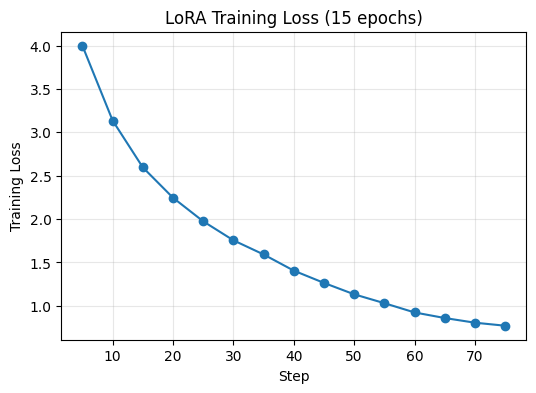

In [31]:
import matplotlib.pyplot as plt

log_history = [entry for entry in trainer.state.log_history if "loss" in entry]
steps = [entry["step"] for entry in log_history]
losses = [entry["loss"] for entry in log_history]

plt.figure(figsize=(6, 4))
plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("LoRA Training Loss (15 epochs)")
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
print(pick_style_cue_doc)

<function pick_style_cue_doc at 0x7d5028ea9e40>


# Section 7: Generation
Generate stories with the fine-tuned model -- first on the validation split
(to sanity-check against known reference_story answers), then on the actual
test prompts for submission.

## 7.1 Generate on validation split
Check output quality against real reference_story answers we already know,
before generating on the actual test set.

In [33]:
def generate_story(row, docs_df, train_df=None, context_chars=250, max_new_tokens=100, min_words=15):
    doc_text = docs_df.loc[docs_df["document_id"] == row["document_id"], "text"].iloc[0]
    prompt_text = (
        f"Theme: {row['theme']} | Region: {row['culture_region']}\n"
        f"Prompt: {row['prompt']}\n"
        f"Style cue: {doc_text[:context_chars]}\n"
        f"Story:"
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,      # penalizes repeating the same tokens/phrases
            no_repeat_ngram_size=3,      # hard-blocks any 3-word phrase from repeating
            pad_token_id=tokenizer.eos_token_id,
        )
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)
    raw_story = full_text.split("Story:")[-1].strip()
    lines = [l.strip() for l in raw_story.split("\n") if l.strip()]

    story = lines[0] if lines else raw_story
    if len(story.split()) < min_words and len(lines) > 1:
        story = story + " " + lines[1]
    return story

for _, row in val_split.iterrows():
    generated = generate_story(row, documents)
    print("PROMPT:", row["prompt"])
    print("REFERENCE:", row["reference_story"])
    print("GENERATED:", generated)
    print("-" * 80)

PROMPT: Write a community tale about a drum choosing the harvest dancer.
REFERENCE: Villagers argued whose son would lead the harvest dance. The drum was placed open; the first barefoot child to match its heartbeat led the circle. No family owned the rhythm that day. Leadership followed listening, not shouting.
GENERATED: Villager children matched the drum's heartbeat at harvest time instead of arguing lineage. Listening leadership became custom and each feast ended with one foot bare on the shared mat.
--------------------------------------------------------------------------------
PROMPT: Tortoise wants the river festival — how does it end?
REFERENCE: Tortoise floated on calabashes, was humbled by fish, and walked the last path with villagers reminding him pride floats briefly.
GENERATED: Calves carried by pride are set ashore with laughter. Moral: Humility floats; arrogance sinks.
--------------------------------------------------------------------------------
PROMPT: Write a fable 

## 7.2 Visualize generated story length vs. target
Check how generated word counts compare to the ~60-120 word target range --
quick way to spot a systematic length problem across all outputs at once.

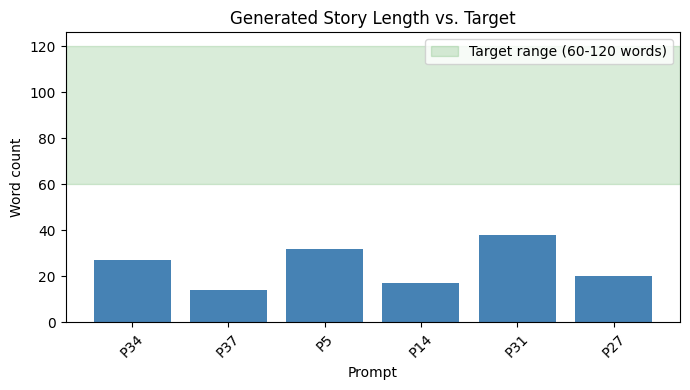

Average length: 24.666666666666668 words


In [34]:
import matplotlib.pyplot as plt

lengths = [len(generate_story(row, documents).split()) for _, row in val_split.iterrows()]
labels = [f"P{row['PromptId']}" for _, row in val_split.iterrows()]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, lengths, color="steelblue")
plt.axhspan(60, 120, color="green", alpha=0.15, label="Target range (60-120 words)")
plt.xlabel("Prompt")
plt.ylabel("Word count")
plt.title("Generated Story Length vs. Target")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average length:", sum(lengths) / len(lengths), "words")

In [35]:
row = test_prompts[test_prompts["PromptId"] == 1001].iloc[0]
print("Prompt:", row["prompt"], "| Theme:", row["theme"], "| Region:", row["culture_region"])
print("Style cue selected:", pick_style_cue_doc(row, documents))

Prompt: Tell a moral market tale about returning a lost cowrie shell. | Theme: moral_tale | Region: west_africa
Style cue selected: A merchant dropped a cowrie shell in the market dust. A girl pocketed it, then dreamed of her mother's empty grain bowl that night. At sunrise she returned the shell; the merchant gifted a measure of rice to the widow next door.


## 7.3 Generate on test_prompts.csv (real submission generation)
test_prompts.csv has no document_id, so we pick a same-theme document from
documents.csv as the Style cue instead -- same idea as the retrieval
baseline's theme-matching, just applied to grounding the prompt.

In [36]:
import re

# builds a pattern matching any of those known label words followed by a colon, anywhere in the text (not just the start)
LABEL_PATTERN = re.compile(
    r"\b(Moral|Metaphor|Lesson|Response|Fable|Hero|Heroine|Community|Motto|Teaching|Dialogue|Tale|Ending|Theme|Region|Analysis|Explanation)\s*:\s*",
    re.IGNORECASE,
)

def clean_story(story):
    # If a leaked label appears anywhere, treat everything from that point
    # onward as unwanted meta-commentary and cut it off entirely -- these
    # labels always appear appended after a complete story, never mid-sentence,
    # so truncating is safe and recovers the clean part.
    match = LABEL_PATTERN.search(story)
    if match:
        story = story[:match.start()].strip()
    # Strip any leftover markdown bold markers (e.g. "**") that sometimes
    # surround a leaked label.
    story = re.sub(r"\*+", "", story).strip()
    return story

def generate_story_for_test(row, docs_df, max_new_tokens=100, min_words=15):
    doc_text = pick_style_cue_doc(row, docs_df)
    prompt_text = (
        f"Theme: {row['theme']} | Region: {row['culture_region']}\n"
        f"Prompt: {row['prompt']}\n"
        f"Style cue: {doc_text}\n"
        f"Story:"
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            #min_new_tokens=40,          # <-- new line added here
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
        )
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)
    raw_story = full_text.split("Story:")[-1].strip()
    lines = [l.strip() for l in raw_story.split("\n") if l.strip()]

    story = lines[0] if lines else raw_story
    # Safeguard: if the first line is suspiciously short, take the next line too (still well short of a hallucinated section).
    if len(story.split()) < min_words and len(lines) > 1:
        story = story + " " + lines[1]

    story = clean_story(story)
    return story

test_stories = []
for _, row in test_prompts.iterrows():
    story = generate_story_for_test(row, documents)
    test_stories.append(story)
    print("PROMPT:", row["prompt"])
    print("GENERATED:", story)
    print("-" * 80)

test_prompts["Story"] = test_stories

PROMPT: Tell a moral market tale about returning a lost cowrie shell.
GENERATED: Returning a lost shell led to rice for a widow and trust with merchants. Small acts on time become community harvest.
--------------------------------------------------------------------------------
PROMPT: Create a hero story of an orphan who saves fishermen in a squall.
GENERATED: An orphaned weaver spun rope at sunrise to repay borrowed thread; when a storm lost the chief boat, she led the rescue with lines memorized by night. Skill served rather than name on the harbor wall.
--------------------------------------------------------------------------------
PROMPT: Create an East African tale of hare claiming thunder for himself.
GENERATED: Hare borrowed thunder in a hollow drum; Elephant listened and returned the rhythm to grazing herds. Hare ran away empty-bellied, humbled by elephant's wisdom.
--------------------------------------------------------------------------------
PROMPT: Hyena jumps at the mo

## 7.4 Automated output quality check
Flags leaked labels, length outliers, repetition loops, and garbled text
across all generated stories -- so review means checking flagged rows only.


In [37]:
import re

def flag_issues(story, min_words=15, max_words=120):
    issues = []
    if re.search(r"\b(Theme|Region|Moral|Metaphor|Lesson|Response|Fable|Hero|Heroine|Community|Motto|Teaching|Dialogue|Tale|Ending|Analysis|Explanation)\s*:", story, re.IGNORECASE):
        issues.append("leaked label")
    word_count = len(story.split())
    if word_count < min_words:
        issues.append(f"too short ({word_count} words)")
    if word_count > max_words:
        issues.append(f"too long ({word_count} words)")
    if re.search(r"\b(\w+\s+){2,}\1{2,}", story):
        issues.append("repetition loop")
    if re.search(r"\b[a-zA-Z]*\d[a-zA-Z]+\b|\b[a-zA-Z]+\d[a-zA-Z]*\b", story):
        issues.append("possible garbled text")
    if not story.rstrip().endswith((".", "!", "?", '"')):
        issues.append("cut off mid-sentence")
    words = story.lower().split()
    if len(words) >= 6:
        for n in (3, 4):
            phrases = [" ".join(words[i:i+n]) for i in range(len(words) - n + 1)]
            if len(phrases) != len(set(phrases)):
                issues.append(f"near-duplicate {n}-word phrase")
                break
    return issues

flagged_count = 0
for _, row in test_prompts.iterrows():
    problems = flag_issues(row["Story"])
    if problems:
        flagged_count += 1
        print(f"PromptId {row['PromptId']}: {problems}")
        print(row["Story"])
        print("-" * 40)

print(f"\n{flagged_count} of {len(test_prompts)} stories flagged for review.")


0 of 10 stories flagged for review.


## 7.5 Validate and save fine-tuned submission
Same checks as the baseline -- confirm format is exactly right before
writing the file, so we don't waste a submission on a mistake.


In [38]:
final_submission = test_prompts[["PromptId", "Story"]].copy()

assert list(final_submission.columns) == ["PromptId", "Story"]
assert len(final_submission) == len(test_prompts)
assert final_submission["PromptId"].tolist() == test_prompts["PromptId"].tolist()
assert final_submission["PromptId"].is_unique
assert final_submission["Story"].notna().all()
assert (final_submission["Story"].str.strip() != "").all()   # catch any accidentally-empty strings, not just NaN

output_path = OUTPUT_DIR / "submission.csv"
final_submission.to_csv(output_path, index=False)
print(f"Validated and saved {len(final_submission)} rows -> {output_path}")
print(final_submission)

Validated and saved 10 rows -> /kaggle/working/submission.csv
   PromptId                                              Story
0      1001  Returning a lost shell led to rice for a widow...
1      1002  An orphaned weaver spun rope at sunrise to rep...
2      1003  Hare borrowed thunder in a hollow drum; Elepha...
3      1004  Hyenas watched by starlight after washing humb...
4      1005  Monkeys promise yet pilfer from bee hives unti...
5      1006  Stars spilled from a covered Calabash — not to...
6      1007  Singing softened the path; rivers bend to reme...
7      1008  Widening a path for pride brought dust until n...
8      1009  Gratitude on baobab drums summoned gentle rain...
9      1010  Barefoot children chose the harvest drum becau...


# Section 8: Sampling-based generation with candidate selection
Generate several candidate stories per prompt instead of one greedy output,
then pick the best. First tested on validation data (where we know the true
answer) to confirm this approach actually helps before using it for real.

## 8.1 Levenshtein distance helper
Simple, dependency-free implementation -- we've hit enough library version
issues today that writing our own small function is safer than risking
another install/version mismatch.

In [39]:
def levenshtein(s1, s2):
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

**Note:** Same caveat as 7.1 -- `val_split` is no longer a genuine holdout
since Section 6.4 trains on all 38 examples. This section's earlier
conclusion (best-of-5 sampling not worth adopting) was reached before this
change, using a valid holdout at the time. Not re-run under the current
training configuration.


## 8.2 Test sampling on validation set (oracle check)
Generate 5 candidates per validation prompt using sampling, measure each
against the REAL reference_story, and see if the best-of-5 beats greedy
decoding's single output. This tells us the upper bound of this approach.

In [40]:
def generate_candidates(row, docs_df, k=5, temperature=0.7, max_new_tokens=100):
    doc_text = docs_df.loc[docs_df["document_id"] == row["document_id"], "text"].iloc[0]
    prompt_text = (
        f"Theme: {row['theme']} | Region: {row['culture_region']}\n"
        f"Prompt: {row['prompt']}\n"
        f"Style cue: {doc_text[:250]}\n"
        f"Story:"
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            num_return_sequences=k,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
        )
    candidates = []
    for output in outputs:
        full_text = tokenizer.decode(output, skip_special_tokens=True)
        story = full_text.split("Story:")[-1].strip()
        lines = [l.strip() for l in story.split("\n") if l.strip()]
        candidates.append(lines[0] if lines else story)
    return candidates

greedy_distances, oracle_distances = [], []
for _, row in val_split.iterrows():
    candidates = generate_candidates(row, documents)
    distances = [levenshtein(c, row["reference_story"]) for c in candidates]
    oracle_best = min(distances)
    greedy_output = generate_story(row, documents)  # your existing greedy function
    greedy_dist = levenshtein(greedy_output, row["reference_story"])

    greedy_distances.append(greedy_dist)
    oracle_distances.append(oracle_best)
    print(f"Greedy distance: {greedy_dist} | Best-of-{len(candidates)} distance: {oracle_best}")

print(f"\nAvg greedy distance: {sum(greedy_distances)/len(greedy_distances):.1f}")
print(f"Avg oracle best-of-5 distance: {sum(oracle_distances)/len(oracle_distances):.1f}")

Greedy distance: 160 | Best-of-5 distance: 150
Greedy distance: 94 | Best-of-5 distance: 92
Greedy distance: 144 | Best-of-5 distance: 136
Greedy distance: 99 | Best-of-5 distance: 80
Greedy distance: 179 | Best-of-5 distance: 144
Greedy distance: 88 | Best-of-5 distance: 70

Avg greedy distance: 127.3
Avg oracle best-of-5 distance: 112.0


**Conclusion:** Across our validation split, best-of-5 sampling only modestly
beat greedy decoding (small single-digit percentage gain), and underperformed
greedy on roughly a third of examples -- and that gain assumed an oracle with
perfect knowledge of the correct answer. Not adopted in the final pipeline --
greedy decoding remains the generation method used for actual submissions.